# RNN from scratch

This notebook implements an RNN without using any deep learning frameworks.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

### Create toy dataset

In [21]:
train_data = {
  'good': True,
  'bad': False,
  'happy': True,
  'sad': False,
  'not good': False,
  'not bad': True,
  'not happy': False,
  'not sad': True,
  'very good': True,
  'very bad': False,
  'very happy': True,
  'very sad': False,
  'i am happy': True,
  'this is good': True,
  'i am bad': False,
  'this is bad': False,
  'i am sad': False,
  'this is sad': False,
  'i am not happy': False,
  'this is not good': False,
  'i am not bad': True,
  'this is not sad': True,
  'i am very happy': True,
  'this is very good': True,
  'i am very bad': False,
  'this is very sad': False,
  'this is very happy': True,
  'i am good not bad': True,
  'this is good not bad': True,
  'i am bad not good': False,
  'i am good and happy': True,
  'this is not good and not happy': False,
  'i am not at all good': False,
  'i am not at all bad': True,
  'i am not at all happy': False,
  'this is not at all sad': True,
  'this is not at all happy': False,
  'i am good right now': True,
  'i am bad right now': False,
  'this is bad right now': False,
  'i am sad right now': False,
  'i was good earlier': True,
  'i was happy earlier': True,
  'i was bad earlier': False,
  'i was sad earlier': False,
  'i am very bad right now': False,
  'this is very good right now': True,
  'this is very sad right now': False,
  'this was bad earlier': False,
  'this was very good earlier': True,
  'this was very bad earlier': False,
  'this was very happy earlier': True,
  'this was very sad earlier': False,
  'i was good and not bad earlier': True,
  'i was not good and not happy earlier': False,
  'i am not at all bad or sad right now': True,
  'i am not at all good or happy right now': False,
  'this was not happy and not good earlier': False,
}

test_data = {
  'this is happy': True,
  'i am good': True,
  'this is not happy': False,
  'i am not good': False,
  'this is not bad': True,
  'i am not sad': True,
  'i am very good': True,
  'this is very bad': False,
  'i am very sad': False,
  'this is bad not good': False,
  'this is good and happy': True,
  'i am not good and not happy': False,
  'i am not at all sad': True,
  'this is not at all good': False,
  'this is not at all bad': True,
  'this is good right now': True,
  'this is sad right now': False,
  'this is very bad right now': False,
  'this was good earlier': True,
  'i was not happy and not good earlier': False,
}

Find unique words in dataset and convert them to one-hot vectors

In [22]:
words = {
    word
    for data in (train_data, test_data)
    for key in data.keys()
    for word in key.split()
}

identity = np.identity(len(words))
one_hot_encoder = {word: vector for word, vector in zip(words, identity)}

X_train = [np.array([one_hot_encoder[word] for word in key.split()]) for key in train_data.keys()]
y_train = np.array([1 if value else 0 for value in train_data.values()])
X_test = [np.array([one_hot_encoder[word] for word in key.split()]) for key in test_data.keys()]
y_test = np.array([1 if value else 0 for value in test_data.values()])

vocab_size = len(words)

### Create model

In [ ]:
def relu(x):
    return np.maximum(x, 0)

def binary_cross_entropy_loss(y_pred_logit, y_true):
    # This is a numerically stable implementation.
    # An unstable implementation would look like this:
    # return -(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))

    return max(y_pred_logit, 0) - y_pred_logit * y_true + np.log(1 + np.exp(-abs(y_pred_logit)))

def sigmoid(z):
    # This is a numerically stable implementation.
    # An unstable implementation would look like this:
    # return 1 / (1 + np.exp(-z))

    return np.exp(min(z, 0)) / (1 + np.exp(-abs(z)))

class RNN():
    # Notation:
    # T = length of sequence
    # D = input size
    # H = hidden size
    # L = loss function
    # Each vector/matrix has an inline comment showing its dimensions.

    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size

        scale = 0.01
        rng = np.random.default_rng()

        self.Wxh = rng.normal(size=(input_size, hidden_size), scale=scale) # D x H
        self.Whh = rng.normal(size=(hidden_size, hidden_size), scale=scale) # H x H
        self.Why = rng.normal(size=hidden_size, scale=scale) # H

        self.bh = rng.normal(size=hidden_size, scale=scale) # H
        self.by = rng.normal(size=output_size, scale=scale) # 1
    
    def forward(self, X):
        # X: T x D
        h = np.zeros(self.hidden_size) # H
        self.inputs = X # T x D
        self.sequence_length = X.shape[0] # T
        self.cache = np.empty((self.sequence_length + 1, self.hidden_size)) # (T + 1) x H
        self.cache[0] = h
        for i, x in enumerate(X):
            h = relu(x @ self.Wxh + h @ self.Whh + self.bh) # H
            self.cache[i + 1] = h
        y_pred_logit = h @ self.Why + self.by # 1
        y_pred_prob = sigmoid(y_pred_logit)
        return y_pred_logit, y_pred_prob

    def backward1(self, p, c, learning_rate=0.01):
        dL_dy = p - c # 1

        dL_dWhy = dL_dy * self.cache[-1] # H
        dL_dby = dL_dy # 1

        d_activation = (self.cache[1:] > 0).astype(float) # T x H
        dy_dh = self.Why # H
        dL_dh = dL_dy * dy_dh # H

        dL_dWxh = np.zeros(self.Wxh.shape) # D x H
        dL_dWhh = np.zeros(self.Whh.shape) # H x H
        dL_dbh = np.zeros(self.bh.shape) # H

        for i in reversed(range(self.sequence_length)):
            dL_dz = d_activation[i] * dL_dh # H
            dL_dbh += dL_dz # H
            dL_dWxh += np.outer(self.inputs[i], dL_dz) # D x H
            dL_dWhh += np.outer(self.cache[i], dL_dz) # H x H
            dL_dh = self.Whh @ dL_dz # H

        self.Why -= learning_rate * dL_dWhy
        self.by -= learning_rate * dL_dby
        self.Wxh -= learning_rate * dL_dWxh
        self.Whh -= learning_rate * dL_dWhh
        self.bh -= learning_rate * dL_dbh

### Train and test model

In [ ]:
input_size = vocab_size
hidden_size = 64
output_size = 1
epochs = 500
learning_rate = 0.01
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

rnn = RNN(input_size, hidden_size, output_size)

for epoch in range(epochs):
    # Train
    train_loss = 0
    correct = 0
    for X, y_pred_logit in zip(X_train, y_train):
        y_pred_logit, y_pred_prob = rnn.forward(X)
        classification = y_pred_prob.round()
        train_loss += binary_cross_entropy_loss(y_pred_logit, y_pred_logit).item()
        correct += (classification == y_pred_logit).sum().item()
        rnn.backward1(y_pred_prob, y_pred_logit, learning_rate)
    train_accuracy = correct / len(X_train)
    average_train_loss = train_loss / len(X_train)
    train_losses.append(average_train_loss)
    train_accuracies.append(train_accuracy)

    # Test
    test_loss = 0
    correct = 0
    for X, y_pred_logit in zip(X_test, y_test):
        y_pred_logit, y_pred_prob = rnn.forward(X)
        classification = y_pred_prob.round()
        test_loss += binary_cross_entropy_loss(y_pred_logit, y_pred_logit).item()
        correct += (classification == y_pred_logit).sum().item()
    test_accuracy = correct / len(X_test)
    average_test_loss = test_loss / len(X_test)
    test_losses.append(average_test_loss)
    test_accuracies.append(test_accuracy)

    if epoch % 100 == 99:
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"Training loss: {average_train_loss:.2f}")
        print(f"Testing loss: {average_test_loss:.2f}")
        print(f"Training accuracy: {train_accuracy:.0%}")
        print(f"Testing accuracy: {test_accuracy:.0%}")
        print()

Epoch 100/500
Training loss: 0.69
Testing loss: 0.70
Training accuracy: 55%
Testing accuracy: 50%

Epoch 200/500
Training loss: 0.68
Testing loss: 0.70
Training accuracy: 53%
Testing accuracy: 50%

Epoch 300/500
Training loss: 0.36
Testing loss: 0.39
Training accuracy: 88%
Testing accuracy: 90%

Epoch 400/500
Training loss: 0.02
Testing loss: 0.03
Training accuracy: 100%
Testing accuracy: 100%

Epoch 500/500
Training loss: 0.01
Testing loss: 0.01
Training accuracy: 100%
Testing accuracy: 100%



### Visualize results

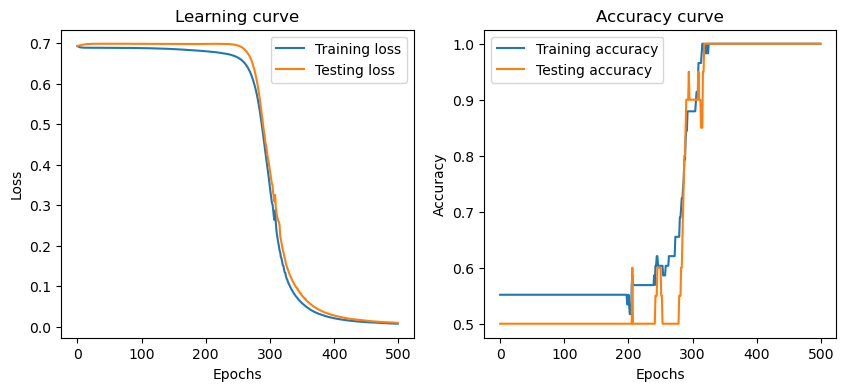

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_title("Learning curve")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.plot(train_losses, label="Training loss")
ax1.plot(test_losses, label="Testing loss")
ax1.legend()

ax2.set_title("Accuracy curve")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.plot(train_accuracies, label="Training accuracy")
ax2.plot(test_accuracies, label="Testing accuracy")
ax2.legend()

plt.show()


### Sources
- https://victorzhou.com/blog/intro-to-rnns/
- https://www.youtube.com/watch?v=Wu9BsMSKqyk
- https://www.quarkml.com/2023/08/backpropagation-through-time-explained-with-derivations.html
- https://d2l.ai/chapter_recurrent-neural-networks/bptt.html